# Storms of High-Energy Particles - Performance Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
sequential_df = pd.read_csv("data_sequential.csv")

# Clean the dataset.
for col in sequential_df.columns:
    if col != "test":
        sequential_df[col] = sequential_df[col].astype(str).str.replace(',', '.').astype(float)

## OpenMP+MPI Implementation

### Speedup

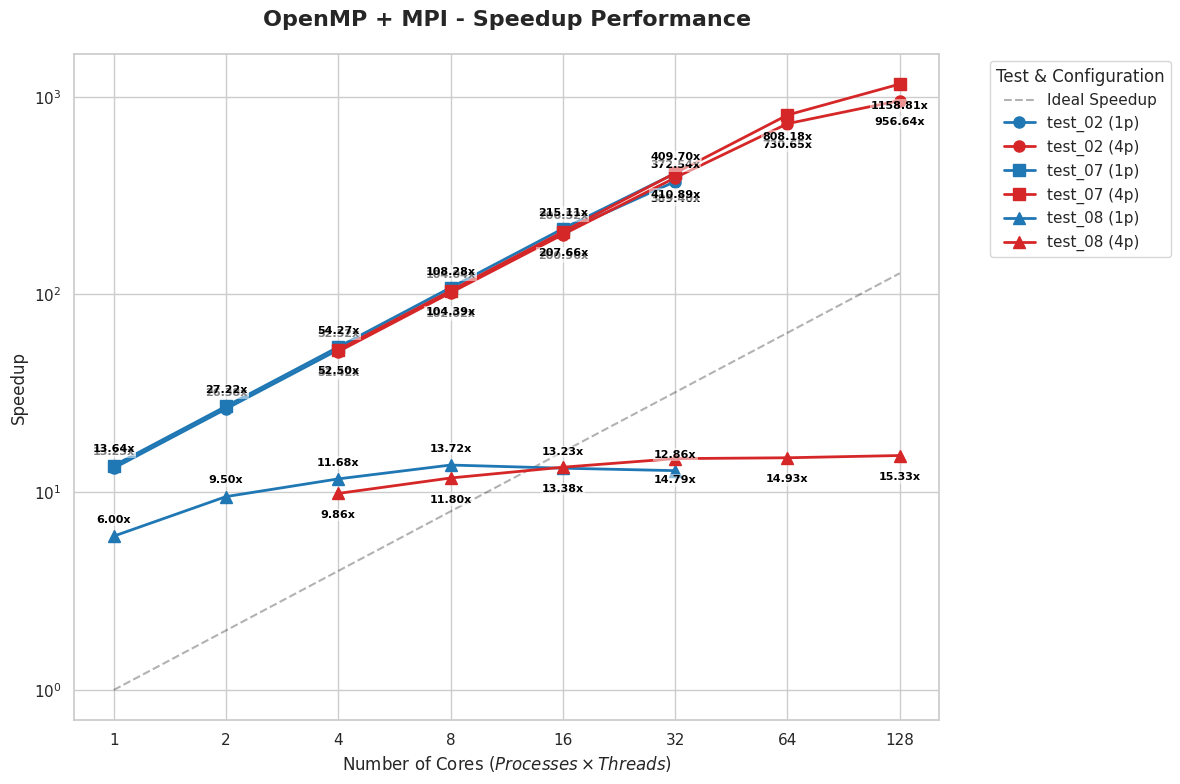

In [3]:
# Extract the target tests and take the average sequential execution time.
target_tests = ["test_02", "test_07", "test_08"]
sequential_times = sequential_df[sequential_df['test'].isin(target_tests)].set_index('test')['avg'].to_dict()

# Load the OpenMP+MPI datasets to compute the speedup for the target tests for each process/thread combination.
h1_df = pd.read_csv('data_hybrid_1.csv')
h4_df = pd.read_csv('data_hybrid_4.csv')
h1_df = h1_df[h1_df['test'].isin(target_tests)].copy()
h4_df = h4_df[h4_df['test'].isin(target_tests)].copy()

# Compute the total number of cores for each configuration in the datasets.
h1_df['type'] = 'hybrid1'
h1_df['cores'] = 1 * h1_df['threads']

h4_df['type'] = 'hybrid4'
h4_df['cores'] = 4 * h4_df['threads']

# Combine the datasets for simplicity and compute the speedup.
hybrid_summary = pd.concat([h1_df, h4_df])
hybrid_summary['speedup'] = hybrid_summary.apply(lambda row: sequential_times[row['test']] / row['avg'], axis=1)

# Set visualization configurations, such as label positions and test identifiers.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

test_markers = {'test_02': 'o', 'test_07': 's', 'test_08': '^'}
type_colors = {'hybrid1': '#1f77b4', 'hybrid4': '#d62728'}

all_cores = sorted(hybrid_summary['cores'].unique())

# Start by plotting the ideal linear speed-up.
plt.plot(all_cores, all_cores, linestyle='--', color='black', label='Ideal Speedup', alpha=0.3, zorder=1)

for (test_id, h_type), group in hybrid_summary.groupby(['test', 'type']):
    group = group.sort_values('cores')
    label = f"{test_id} ({'1p' if h_type=='hybrid1' else '4p'})"
    
    plt.plot(group['cores'], group['speedup'], 
             marker=test_markers[test_id],
             color=type_colors[h_type], label=label,
             markersize=8, linewidth=2)
    
    # Adding bold text labels for speedup values.
    va = 'bottom' if h_type == 'hybrid1' else 'top'
    y_offset = 8 if h_type == 'hybrid1' else -12
    
    for x, y in zip(group['cores'], group['speedup']):
        plt.annotate(f"{y:.2f}x", 
                     xy=(x, y), 
                     xytext=(0, y_offset), 
                     textcoords="offset points",
                     ha='center', va=va,
                     fontsize=8, fontweight='bold',
                     color='black',
                     # Optional: adds a tiny white glow to make text readable over lines.
                     bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))

# Add final details.
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xticks(all_cores, all_cores)

plt.xlabel('Number of Cores ($Processes \\times Threads$)', fontsize=12)
plt.ylabel('Speedup', fontsize=12)
plt.title('OpenMP + MPI - Speedup Performance', fontsize=16, fontweight='bold', pad=20)
plt.legend(title='Test & Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# Save the resulting image.
plt.savefig('plots/mpi_omp_speedup.png', dpi=300)

### Efficiency

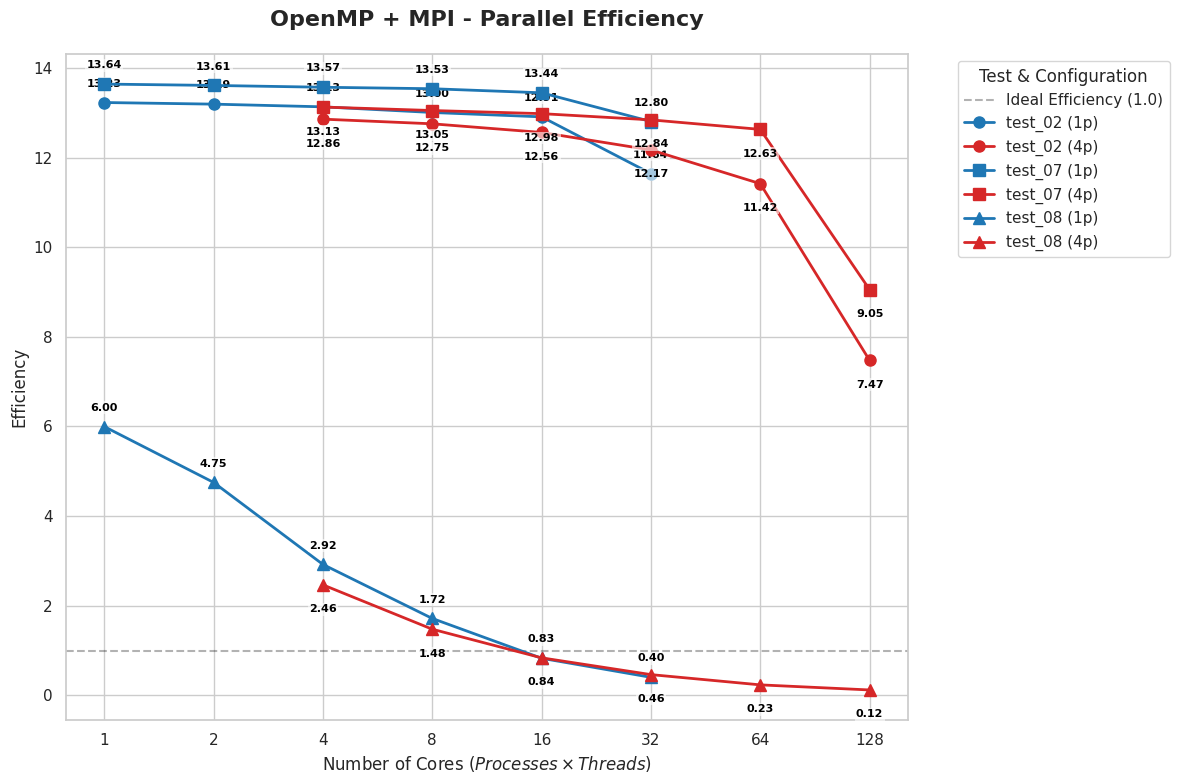

In [4]:
# Compute efficiency as the ratio between the speedup and the number of cores.
hybrid_summary['efficiency'] = hybrid_summary['speedup'] / hybrid_summary['cores']

# Set visualization configurations, such as label positions and test identifiers.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

test_markers = {'test_02': 'o', 'test_07': 's', 'test_08': '^'}
type_colors = {'hybrid1': '#1f77b4', 'hybrid4': '#d62728'}
all_cores = sorted(hybrid_summary['cores'].unique())

# Start by plotting the linear efficiency.
plt.axhline(y=1, color='black', linestyle='--', alpha=0.3, label='Ideal Efficiency (1.0)', zorder=1)

for (test_id, h_type), group in hybrid_summary.groupby(['test', 'type']):
    group = group.sort_values('cores')
    label_suffix = '1p' if h_type == 'hybrid1' else '4p'
    label = f"{test_id} ({label_suffix})"
    
    plt.plot(group['cores'], group['efficiency'], 
             marker=test_markers[test_id], color=type_colors[h_type], label=label,
             markersize=8, linewidth=2, zorder=3)
    
    # Add bold text labels for efficiency.
    va = 'bottom' if h_type == 'hybrid1' else 'top'
    y_offset = 10 if h_type == 'hybrid1' else -14
    
    for x, y in zip(group['cores'], group['efficiency']):
        plt.annotate(f"{y:.2f}", 
                     xy=(x, y), 
                     xytext=(0, y_offset), 
                     textcoords="offset points",
                     ha='center', va=va,
                     fontsize=8, fontweight='bold',
                     color='black',
                     bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# Add final details.
plt.xscale('log', base=2)
plt.xticks(all_cores, all_cores)

plt.xlabel('Number of Cores ($Processes \\times Threads$)', fontsize=12)
plt.ylabel('Efficiency', fontsize=12)
plt.title('OpenMP + MPI - Parallel Efficiency', fontsize=16, fontweight='bold', pad=20)
plt.legend(title='Test & Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('plots/mpi_omp_efficiency.png', dpi=300)
plt.show()

### Scalability

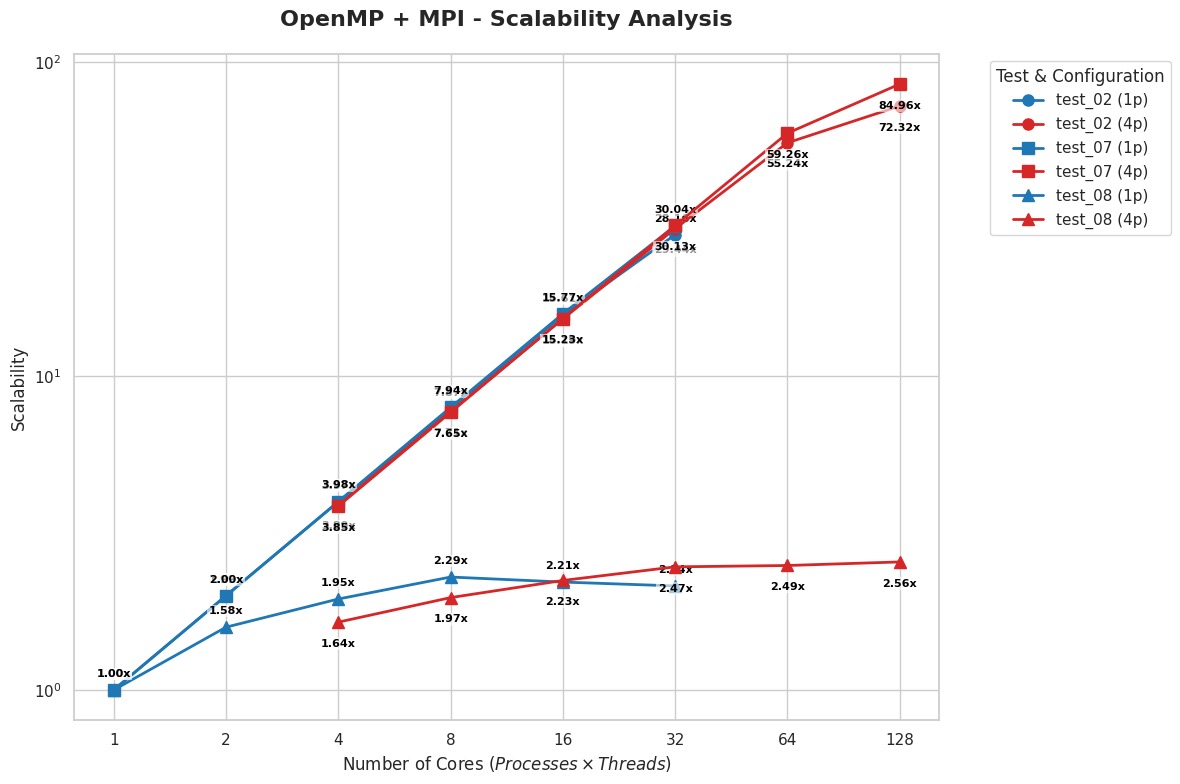

In [5]:
# Extract again the target tests and their parallel baseline, which is the time when one process and one trhead are used.
target_tests = ["test_02", "test_07", "test_08"]
h1_df = pd.read_csv('data_hybrid_1.csv')
h4_df = pd.read_csv('data_hybrid_4.csv')

h1_df = h1_df[h1_df['test'].isin(target_tests)].copy()
h4_df = h4_df[h4_df['test'].isin(target_tests)].copy()

t11_baselines = h1_df[h1_df['threads'] == 1].set_index('test')['avg'].to_dict()

h1_df['type'], h1_df['cores'] = 'hybrid1', 1 * h1_df['threads']
h4_df['type'], h4_df['cores'] = 'hybrid4', 4 * h4_df['threads']

# Compute scalability as the relative speedup in the parallel implementation.
hybrid_summary = pd.concat([h1_df, h4_df])
hybrid_summary['scalability'] = hybrid_summary.apply(lambda row: t11_baselines[row['test']] / row['avg'], axis=1)

# Set visualization configurations, such as lebel positions and test identifiers.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

test_markers = {'test_02': 'o', 'test_07': 's', 'test_08': '^'}
type_colors = {'hybrid1': '#1f77b4', 'hybrid4': '#d62728'}
all_cores = sorted(hybrid_summary['cores'].unique())

for (test_id, h_type), group in hybrid_summary.groupby(['test', 'type']):
    group = group.sort_values('cores')
    label_suffix = '1p' if h_type == 'hybrid1' else '4p'
    label = f"{test_id} ({label_suffix})"
    
    plt.plot(group['cores'], group['scalability'], 
             marker=test_markers[test_id], color=type_colors[h_type], label=label,
             markersize=8, linewidth=2, zorder=3)
    
    # Add bold text labels for scalability
    va = 'bottom' if h_type == 'hybrid1' else 'top'
    y_offset = 8 if h_type == 'hybrid1' else -12
    
    for x, y in zip(group['cores'], group['scalability']):
        plt.annotate(f"{y:.2f}x", 
                     xy=(x, y), 
                     xytext=(0, y_offset), 
                     textcoords="offset points",
                     ha='center', va=va,
                     fontsize=8, fontweight='bold',
                     color='black',
                     bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# Add final details.
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xticks(all_cores, all_cores)

plt.xlabel('Number of Cores ($Processes \\times Threads$)', fontsize=12)
plt.ylabel('Scalability', fontsize=12)
plt.title('OpenMP + MPI - Scalability Analysis', fontsize=16, fontweight='bold', pad=20)
plt.legend(title='Test & Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('plots/mpi_omp_scalability.png', dpi=300)
plt.show()

## CUDA Implementation

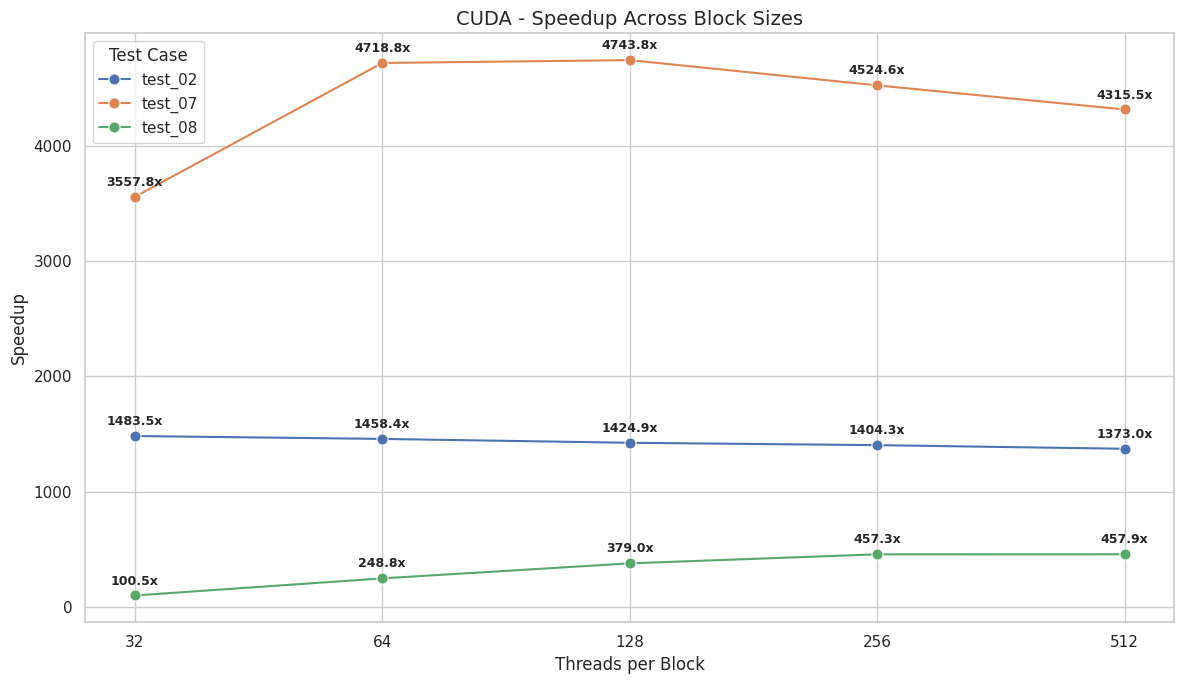

In [6]:
# Extract the target tests and take the average sequential execution time.
target_tests = ["test_02", "test_07", "test_08"]
sequential_times = sequential_df[sequential_df['test'].isin(target_tests)].set_index('test')['avg'].to_dict()

# Load the CUDA datasets and compute the speed-up for the target tests for each block size.
cuda_files = {32: 'data_cuda_32.csv', 64: 'data_cuda_64.csv', 128: 'data_cuda_128.csv', 256: 'data_cuda_256.csv', 512: 'data_cuda_512.csv'}

plot_data = []
for size, file in cuda_files.items():
    cuda_df = pd.read_csv(file)
    cuda_df['avg'] = pd.to_numeric(cuda_df['avg'], errors='coerce')
    
    for test in target_tests:
        cuda_avg = cuda_df.loc[cuda_df['test'] == test, 'avg'].values[0]
        speedup = sequential_times[test] / cuda_avg
        plot_data.append({'Threads per Block': size, 'Test': test, 'Speedup': speedup})

plot_df = pd.DataFrame(plot_data)

# Create and format the line plot.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Create the line plot
lineplot = sns.lineplot(data=plot_df, x='Threads per Block', y='Speedup', 
                        hue='Test', marker='o', markersize=8)

# Set logarithmic scale for x-axis to keep points evenly spaced
plt.xscale('log', base=2)
plt.xticks([32, 64, 128, 256, 512], labels=[32, 64, 128, 256, 512])

# Add Speedup labels for each point
for i in range(plot_df.shape[0]):
    plt.text(
        x=plot_df.iloc[i]['Threads per Block'], 
        y=plot_df.iloc[i]['Speedup'] + (plot_df['Speedup'].max() * 0.02), 
        s=f"{plot_df.iloc[i]['Speedup']:.1f}x", 
        fontsize=9, ha='center', fontweight='bold'
    )

plt.title("CUDA - Speedup Across Block Sizes", fontsize=14)
plt.xlabel("Threads per Block", fontsize=12)
plt.ylabel("Speedup", fontsize=12)
plt.legend(title='Test Case')
plt.tight_layout()

# Save the resulting image.
plt.savefig('plots/cuda_speedup.png')

## Miscellaneous

### Comparisons Between Test Files

In [7]:
# Load and clean the sequential dataset.
sequential_df = pd.read_csv('data_sequential.csv')
for col in sequential_df.columns:
    if col != 'test':
        sequential_df[col] = sequential_df[col].astype(str).str.replace(',', '.').astype(float)

# Load OpenMP + MPI files from directory.
h1_df = pd.read_csv('data_hybrid_1.csv')
h4_df = pd.read_csv('data_hybrid_4.csv')

# Compute the total cores for the OpenMP + MPI version.
h1_df['cores'] = 1 * h1_df['threads']
h4_df['cores'] = 4 * h4_df['threads']

# Load all CUDA files from directory.
cuda_files = glob.glob('data_cuda_*.csv')
cuda_list = []
for f in cuda_files:
    bs = int(f.split('_')[-1].split('.')[0])
    df = pd.read_csv(f)
    df['block_size'] = bs
    cuda_list.append(df)
cuda_df = pd.concat(cuda_list)

# Label formatting.
def format_label(val):
    if val < 0.001:
        return f"{val:.2e}s"
    elif val < 1:
        return f"{val:.4f}s"
    else:
        return f"{val:.2f}s"

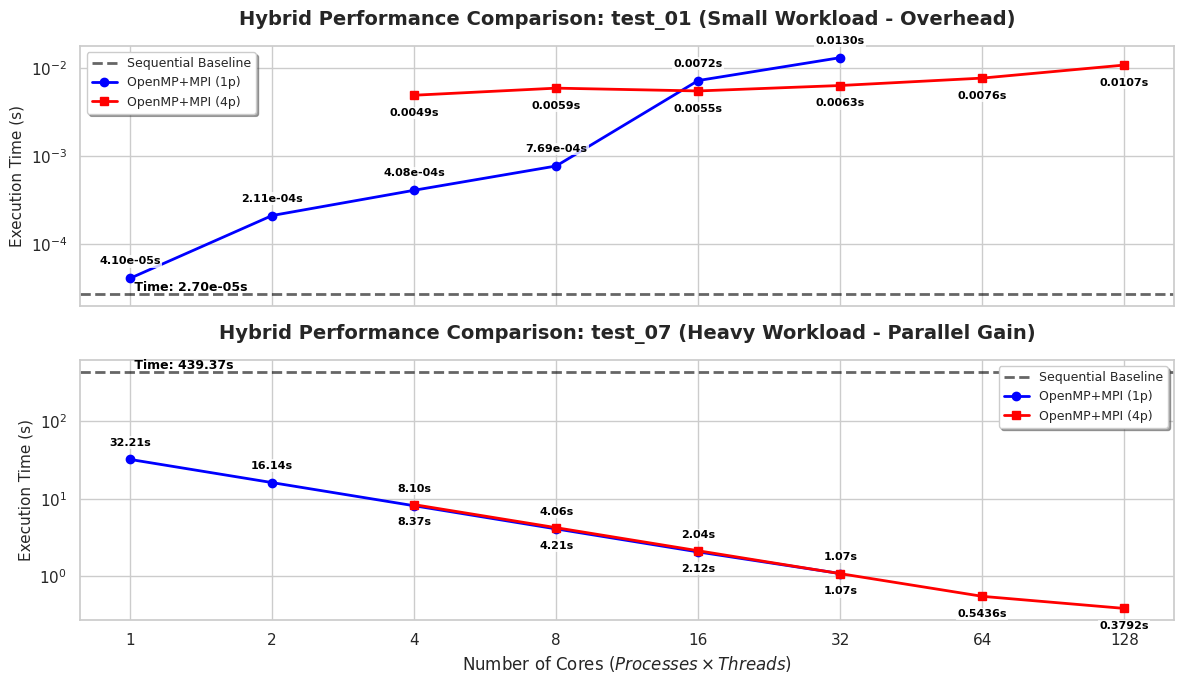

In [12]:
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

all_cores = sorted(list(set(h1_df['cores']) | set(h4_df['cores'])))

for test_id, ax in [('test_01', ax1), ('test_07', ax2)]:
    # Sequential Baseline.
    seq_time = sequential_df[sequential_df['test'] == test_id]['avg'].values[0]
    ax.axhline(y=seq_time, color='black', linestyle='--', linewidth=2, alpha=0.6, label='Sequential Baseline')
    ax.text(all_cores[0], seq_time, f" Time: {format_label(seq_time)}", va='bottom', fontsize=9, fontweight='bold', color='black')
    
    # Plot the times with one process.
    sub1 = h1_df[h1_df['test'] == test_id].sort_values('cores')
    ax.plot(sub1['cores'], sub1['avg'], marker='o', color='blue', label='OpenMP+MPI (1p)', linewidth=2, zorder=3)
    for x, y in zip(sub1['cores'], sub1['avg']):
        ax.annotate(format_label(y), (x, y), xytext=(0, 10), textcoords="offset points", 
                     color='black', fontsize=8, ha='center', fontweight='bold',
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
    
    # Plot the times with four processes.
    sub4 = h4_df[h4_df['test'] == test_id].sort_values('cores')
    ax.plot(sub4['cores'], sub4['avg'], marker='s', color='red', label='OpenMP+MPI (4p)', linewidth=2, zorder=3)
    for x, y in zip(sub4['cores'], sub4['avg']):
        ax.annotate(format_label(y), (x, y), xytext=(0, -15), textcoords="offset points", 
                     color='black', fontsize=8, ha='center', fontweight='bold',
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
    
    # Axis configuration.
    ax.set_yscale('log')
    ax.set_xscale('log', base=2)
    ax.set_xticks(all_cores)
    ax.set_xticklabels(all_cores)
    
    ax.set_ylabel('Execution Time (s)', fontsize=11)
    title_suffix = "(Small Workload - Overhead)" if test_id == 'test_01' else "(Heavy Workload - Parallel Gain)"
    ax.set_title(f"Hybrid Performance Comparison: {test_id} {title_suffix}", fontweight='bold', fontsize=14, pad=15)

    if test_id == 'test_01':
        # Place the legend in the center-left to avoid the rising lines on the right.
        ax.legend(loc='upper left', bbox_to_anchor=(0, 1), frameon=True, shadow=True, fontsize=9, ncol=1)
    else:
        # For test_07, the upper right is usually clear as lines trend downward.
        ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=9, ncol=1)

ax2.set_xlabel('Number of Cores ($Processes \\times Threads$)', fontsize=12)

# Add final details.
plt.tight_layout()
plt.savefig('plots/mpi_omp_comparisons.png', dpi=300)
plt.show()

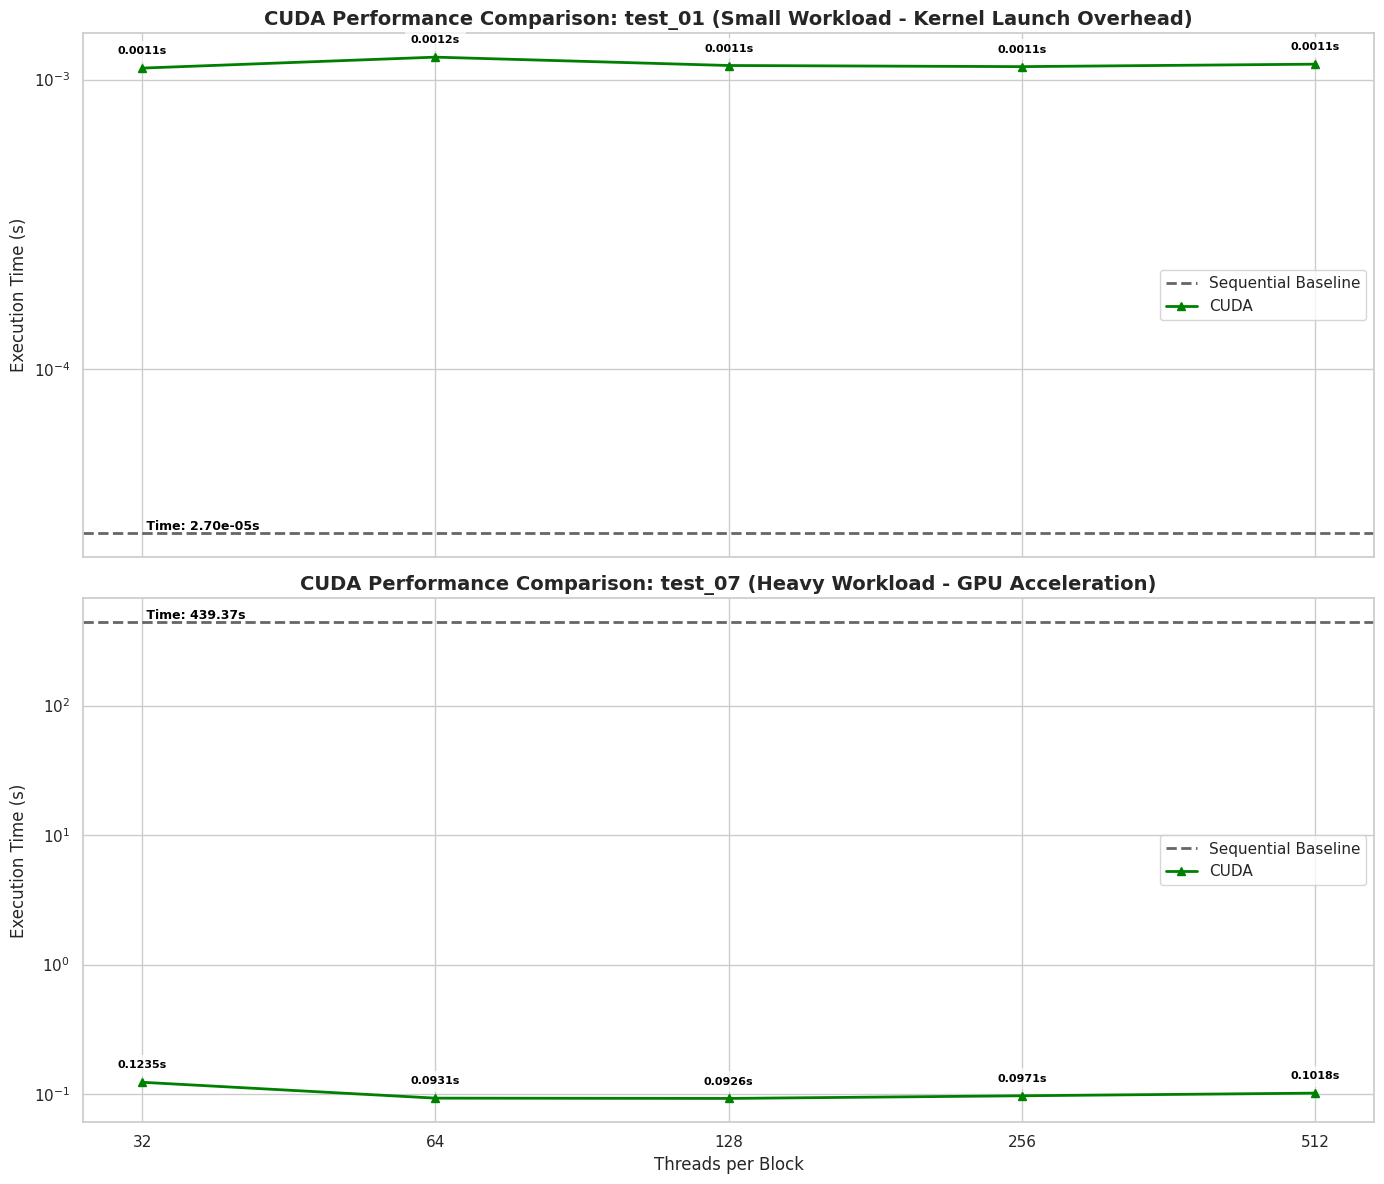

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

for test_id, ax in [('test_01', ax1), ('test_07', ax2)]:
    # Sequential Baseline.
    seq_time = sequential_df[sequential_df['test'] == test_id]['avg'].values[0]
    ax.axhline(y=seq_time, color='black', linestyle='--', linewidth=2, alpha=0.6, label='Sequential Baseline')
    ax.text(32, seq_time, f" Time: {format_label(seq_time)}", va='bottom', fontsize=9, fontweight='bold', color='black')

    # Plot and label the times of the CUDA implementation.
    sub_cuda = cuda_df[cuda_df['test'] == test_id].sort_values('block_size')
    ax.plot(sub_cuda['block_size'], sub_cuda['avg'], marker='^', color='green', label='CUDA', linewidth=2)
    for x, y in zip(sub_cuda['block_size'], sub_cuda['avg']):
        ax.annotate(format_label(y), (x, y), xytext=(0, 10), textcoords="offset points", 
                     color='black', fontsize=8, ha='center', fontweight='bold',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    ax.set_yscale('log')
    ax.set_ylabel('Execution Time (s)')
    title_suffix = "(Small Workload - Kernel Launch Overhead)" if test_id == 'test_01' else "(Heavy Workload - GPU Acceleration)"
    ax.set_title(f"CUDA Performance Comparison: {test_id} {title_suffix}", fontweight='bold', fontsize=14)
    ax.legend()

# Add final details.
ax2.set_xscale('log', base=2)
ax2.set_xticks(sorted(cuda_df['block_size'].unique()))
ax2.set_xticklabels(sorted(cuda_df['block_size'].unique()))
ax2.set_xlabel('Threads per Block')
plt.tight_layout()
plt.savefig('plots/cuda_comparisons.png', dpi=300)

### Comparisons Between Implementations

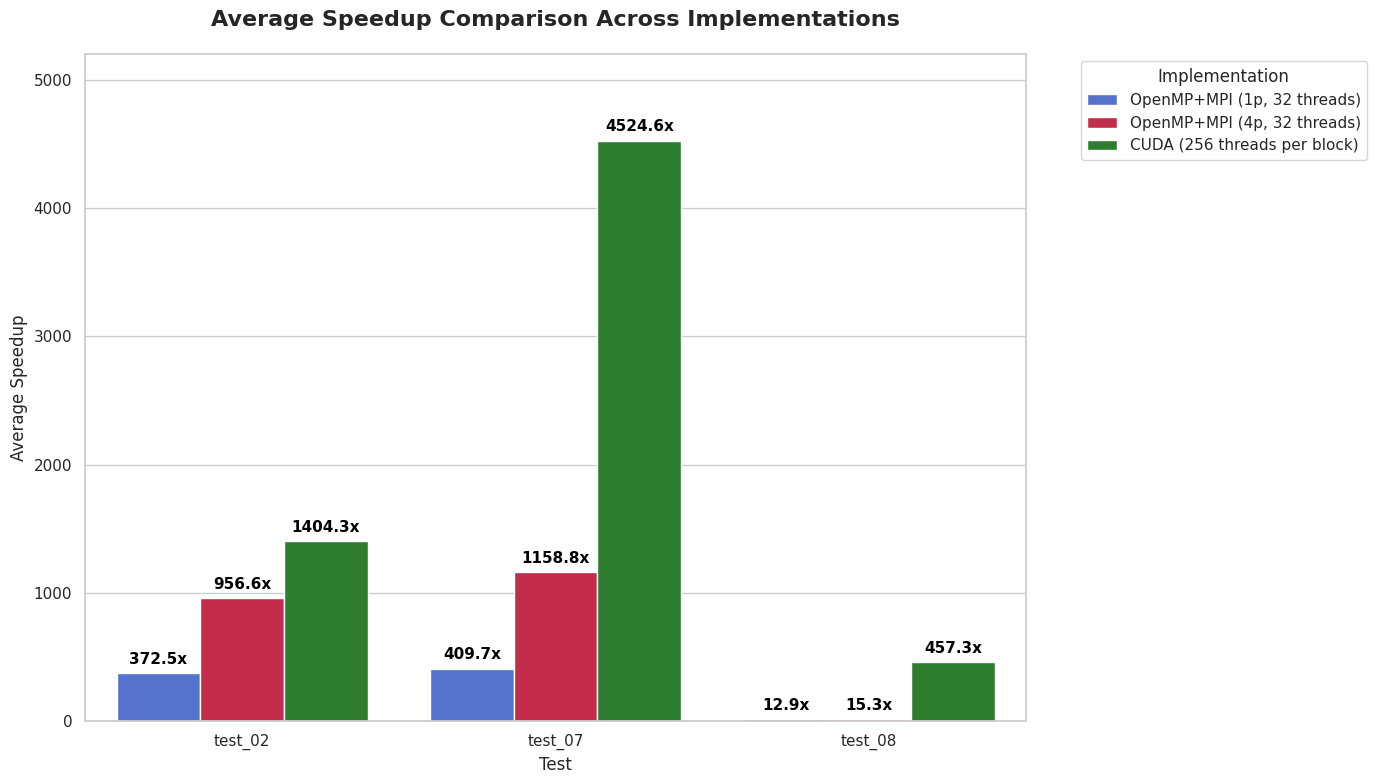

In [14]:
# Extract the target tests.
target_tests = ['test_02', 'test_07', 'test_08']
results = []

for test in target_tests:
    t_seq_avg = sequential_df[sequential_df['test'] == test]['avg'].values[0]
    
    # Hybrid implementation - 1 process, 32 threads.
    t_h1 = h1_df[(h1_df['test'] == test) & (h1_df['threads'] == 32)]['avg'].values[0]
    results.append({'Test': test, 'Implementation': 'OpenMP+MPI (1p, 32 threads)', 'Speedup': t_seq_avg / t_h1})
    
    # Hybrid implementation - 4 processes, 32 threads.
    t_h4 = h4_df[(h4_df['test'] == test) & (h4_df['threads'] == 32)]['avg'].values[0]
    results.append({'Test': test, 'Implementation': 'OpenMP+MPI (4p, 32 threads)', 'Speedup': t_seq_avg / t_h4})
    
    # CUDA implementation - 256 threads per block.
    t_cuda = cuda_df[(cuda_df['test'] == test) & (cuda_df['block_size'] == 256)]['avg'].values[0]
    results.append({'Test': test, 'Implementation': 'CUDA (256 threads per block)', 'Speedup': t_seq_avg / t_cuda})

plot_df = pd.DataFrame(results)

# Create the plot.
plt.figure(figsize=(14, 8))
palette = {'OpenMP+MPI (1p, 32 threads)': 'royalblue', 'OpenMP+MPI (4p, 32 threads)': 'crimson', 'CUDA (256 threads per block)': 'forestgreen'}

ax = sns.barplot(data=plot_df, x='Test', y='Speedup', hue='Implementation', palette=palette)

# Annotate bars with bold black labels.
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}x", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                    fontsize=11, fontweight='bold', color='black')

# Add final details.
plt.title('Average Speedup Comparison Across Implementations', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Average Speedup', fontsize=12)
plt.ylim(0, plot_df['Speedup'].max() * 1.15)
plt.legend(title='Implementation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/speedup_comparisons.png', dpi=300)
plt.show()

### Profiling (OpenMP+MPI)

In [15]:
# Load the profiling summary of the hybrid implementation.
hybrid_summary = pd.read_csv('summary_hybrid.csv')

# Clean formatting for L1 cache misses.
hybrid_summary['l1_misses'] = hybrid_summary['l1_misses'].astype(str).str.replace('.', '', regex=False).astype(int)

# Add the number of cores for each configuration.
hybrid_summary['cores'] = hybrid_summary.apply(lambda row: (1 if row['type'] == 'hybrid1' else 4) * row['threads'], axis=1)

# Filter for the specific tests of interest.
target_tests = ['test_02', 'test_07', 'test_08']
prof_df = hybrid_summary[hybrid_summary['test'].isin(target_tests)].copy()

# Set up plotting constants for consistency.
type_colors = {'hybrid1': 'blue', 'hybrid4': 'red'}
type_labels = {'hybrid1': '1p', 'hybrid4': '4p'}
test_markers = {'test_02': 'o', 'test_07': 's', 'test_08': '^'}
all_threads = sorted(prof_df['cores'].unique())

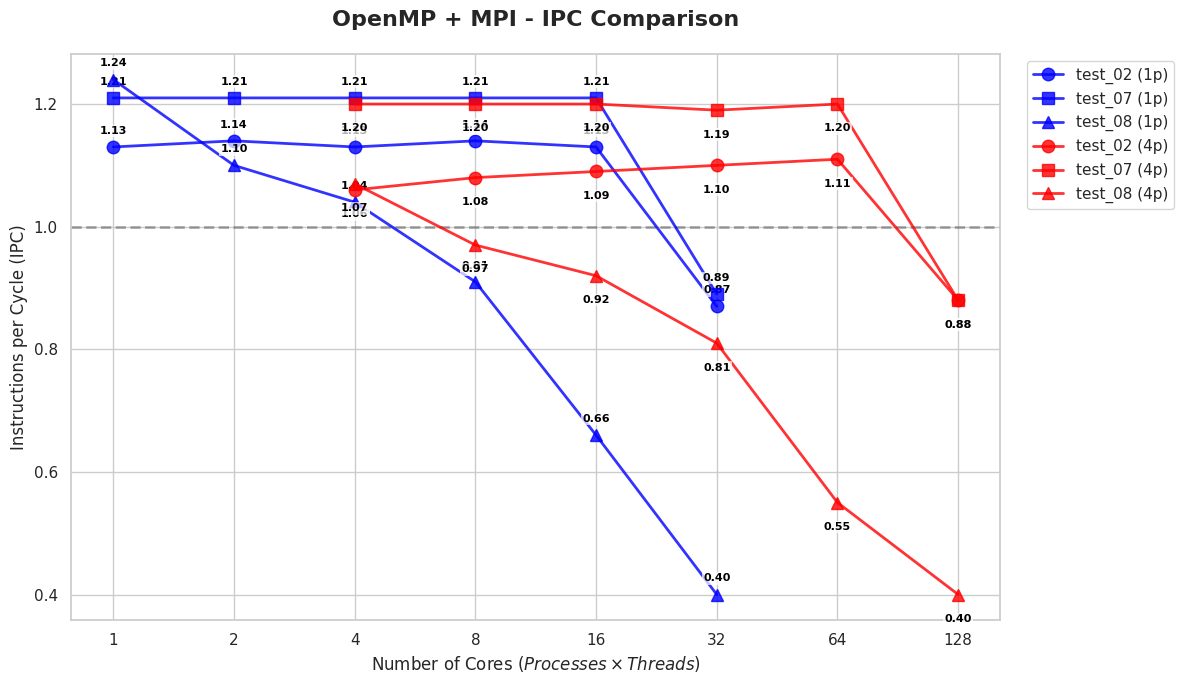

In [16]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Add y = 1 as a baseline.
plt.axhline(y=1, color='black', linestyle='--', linewidth=2, alpha=0.3, zorder=1)

for t_type in ['hybrid1', 'hybrid4']:
    for test in target_tests:
        subset = prof_df[(prof_df['type'] == t_type) & (prof_df['test'] == test)].sort_values('cores')
        
        color = type_colors[t_type]
        label = f"{test} ({type_labels[t_type]})"
        marker = test_markers[test]
        
        plt.plot(subset['cores'], subset['ipc'], marker=marker, color=color, 
                 label=label, markersize=9, linewidth=2, alpha=0.8, zorder=3)
        
        y_offset = 8 if t_type == 'hybrid1' else -14
        va = 'bottom' if t_type == 'hybrid1' else 'top'
        for x, y in zip(subset['cores'], subset['ipc']):
            plt.annotate(f"{y:.2f}", xy=(x, y), xytext=(0, y_offset), 
                         textcoords="offset points", ha='center', va=va,
                         color='black', fontsize=8, fontweight='bold',
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Add final details.
plt.xscale('log', base=2)
plt.xticks(all_cores, all_cores)
plt.xlabel("Number of Cores ($Processes \\times Threads$)", fontsize=12)
plt.ylabel("Instructions per Cycle (IPC)", fontsize=12)
plt.title("OpenMP + MPI - IPC Comparison", fontsize=16, fontweight='bold', pad=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/mpi_omp_ipc_analysis.png', dpi=300)
plt.show()

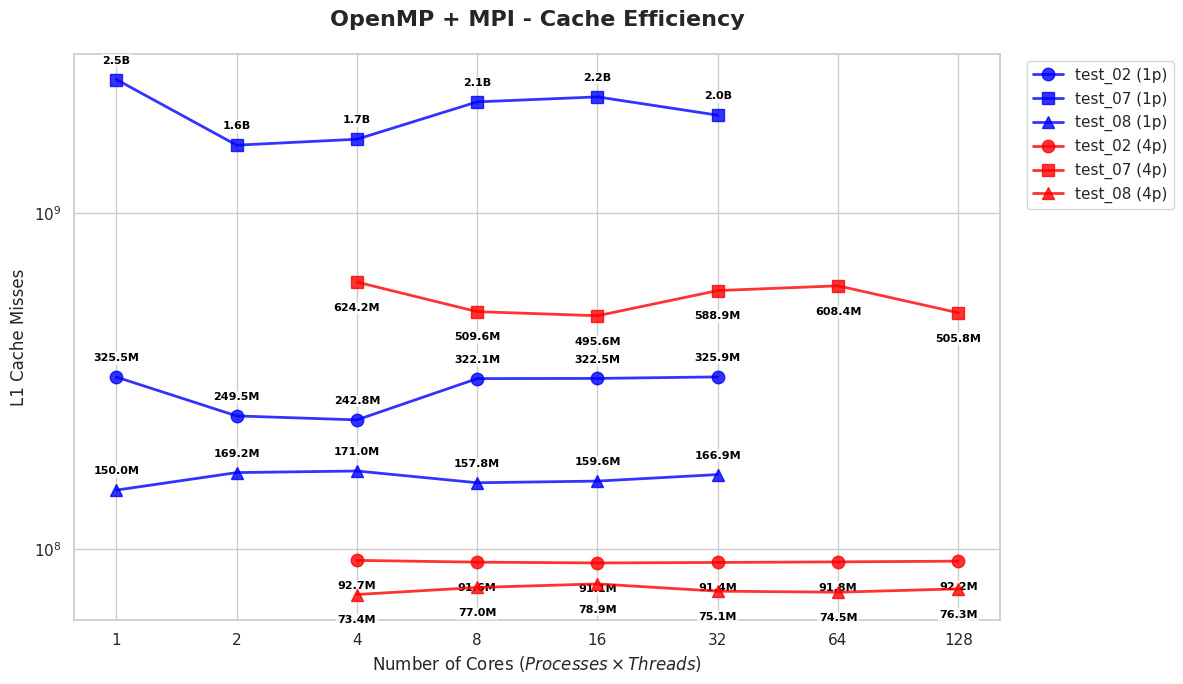

In [19]:
plt.figure(figsize=(12, 7))

for t_type in ['hybrid1', 'hybrid4']:
    for test in target_tests:
        subset = prof_df[(prof_df['type'] == t_type) & (prof_df['test'] == test)].sort_values('cores')
        
        color = type_colors[t_type]
        label = f"{test} ({type_labels[t_type]})"
        marker = test_markers[test]
        
        plt.plot(subset['cores'], subset['l1_misses'], marker=marker, color=color, 
                 label=label, markersize=9, linewidth=2, alpha=0.8, zorder=3)
        
        # Annotate with readable units
        y_offset = 10 if t_type == 'hybrid1' else -15
        va = 'bottom' if t_type == 'hybrid1' else 'top'
        for x, y in zip(subset['cores'], subset['l1_misses']):
            val_label = f"{y/1e9:.1f}B" if y >= 1e9 else f"{y/1e6:.1f}M"
            plt.annotate(val_label, xy=(x, y), xytext=(0, y_offset), 
                         textcoords="offset points", ha='center', va=va,
                         color='black', fontsize=8, fontweight='bold',
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Add final details.
plt.xscale('log', base=2)
plt.yscale('log', base=10) # Use log10 for large magnitude differences
plt.xticks(all_cores, all_cores)
plt.xlabel("Number of Cores ($Processes \\times Threads$)", fontsize=12)
plt.ylabel("L1 Cache Misses", fontsize=12)
plt.title("OpenMP + MPI - Cache Efficiency", fontsize=16, fontweight='bold', pad=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/mpi_omp_cache_misses_analysis.png', dpi=300)
plt.show()

### Profiling (CUDA)

In [20]:
# Load the CUDA statistics dataset.
cuda_stats = pd.read_csv('summary_cuda_stats.csv')

# Clean formatting of float values.
def clean_cuda_val(val):
    if isinstance(val, str):
        parts = val.split('.')
        if len(parts) > 2:
            return float(parts[0] + '.' + parts[1])
        return float(val)
    return val

for col in ['op_htod_ms', 'op_dtod_ms', 'op_dtoh_ms']:
    cuda_stats[col] = cuda_stats[col].apply(clean_cuda_val)

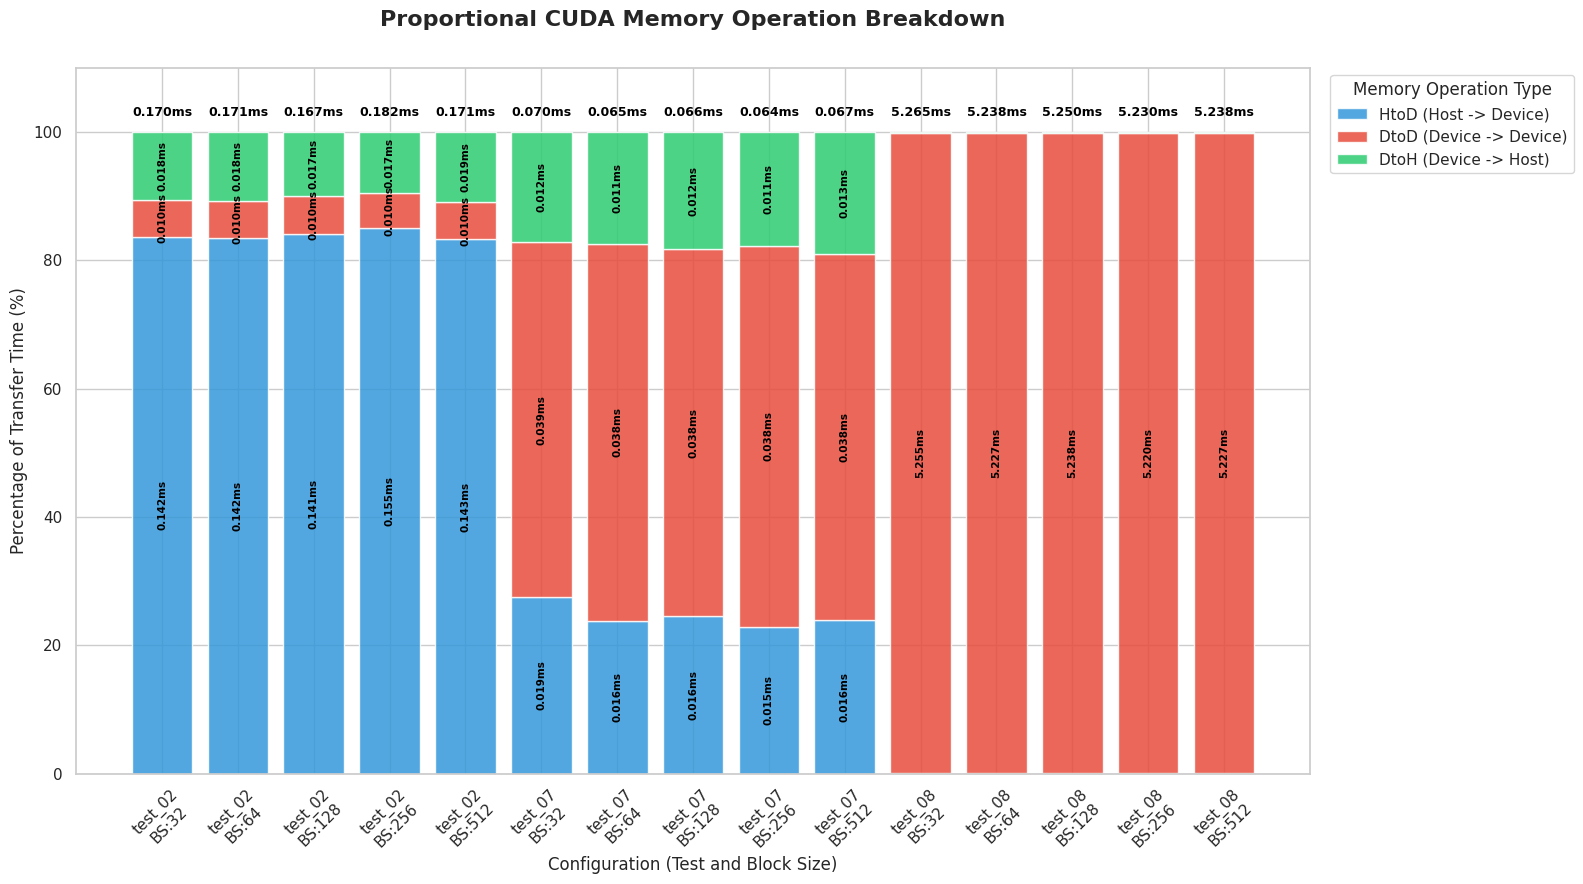

In [21]:
# Calculate memory operation time proportions.
cuda_stats['total_ms'] = cuda_stats['op_htod_ms'] + cuda_stats['op_dtod_ms'] + cuda_stats['op_dtoh_ms']
cuda_stats['htod_p'] = (cuda_stats['op_htod_ms'] / cuda_stats['total_ms']) * 100
cuda_stats['dtod_p'] = (cuda_stats['op_dtod_ms'] / cuda_stats['total_ms']) * 100
cuda_stats['dtoh_p'] = (cuda_stats['op_dtoh_ms'] / cuda_stats['total_ms']) * 100

# Create a new attribute "label" that combines test and block size.
cuda_stats['label'] = cuda_stats['test'] + "\nBS:" + cuda_stats['block_size'].astype(str)

# Create the plot.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 9))

# Create the stacker bars.
bars_htod = plt.bar(cuda_stats['label'], cuda_stats['htod_p'], label='HtoD (Host -> Device)', color='#3498db', alpha=0.85)
bars_dtod = plt.bar(cuda_stats['label'], cuda_stats['dtod_p'], bottom=cuda_stats['htod_p'], 
                    label='DtoD (Device -> Device)', color='#e74c3c', alpha=0.85)
bars_dtoh = plt.bar(cuda_stats['label'], cuda_stats['dtoh_p'], bottom=cuda_stats['htod_p'] + cuda_stats['dtod_p'], 
                    label='DtoH (Device -> Host)', color='#2ecc71', alpha=0.85)

# Add time labels for each operation and total time labels.
for i in range(len(cuda_stats)):
    row = cuda_stats.iloc[i]
    vals = [row['op_htod_ms'], row['op_dtod_ms'], row['op_dtoh_ms']]
    percentages = [row['htod_p'], row['dtod_p'], row['dtoh_p']]
    
    current_bottom = 0
    for val, p in zip(vals, percentages):
        if p > 3: # Segment must be at least 3% to show time.
            plt.text(i, current_bottom + p/2, f"{val:.3f}ms", 
                     ha='center', va='center', rotation=90,
                     fontweight='bold', color='black', fontsize=7.5)
        current_bottom += p
    
    # Place the total value at the top.
    plt.text(i, 102, f"{row['total_ms']:.3f}ms", 
             ha='center', va='bottom', fontweight='bold', color='black', fontsize=9)

# Add final details.
plt.title('Proportional CUDA Memory Operation Breakdown', fontsize=16, fontweight='bold', pad=30)
plt.ylabel('Percentage of Transfer Time (%)', fontsize=12)
plt.xlabel('Configuration (Test and Block Size)', fontsize=12)
plt.ylim(0, 110) # Extra space for total labels.
plt.legend(title='Memory Operation Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('plots/memcpy_breakdown.png', dpi=300)
plt.show()

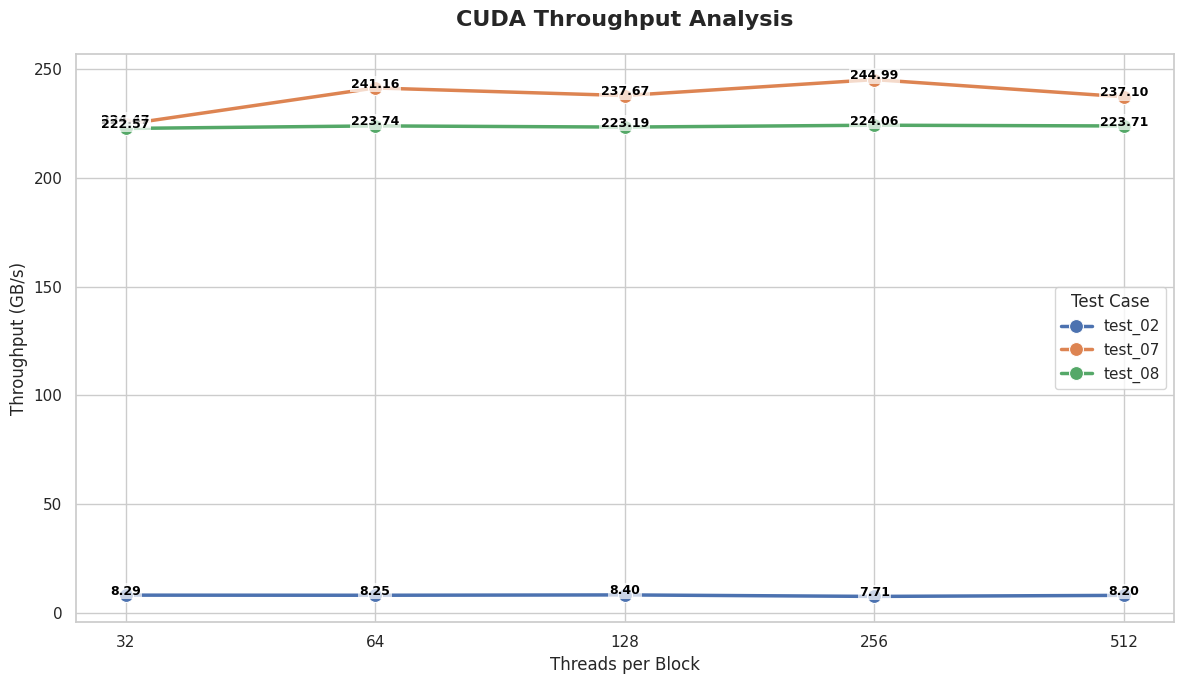

In [22]:
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Create a line plot for throughput.
ax = sns.lineplot(data=cuda_stats, x='block_size', y='throughput_gbs', hue='test', 
                  marker='o', markersize=10, linewidth=2.5)

# Add bold labels for the throughput values.
for test in cuda_stats['test'].unique():
    subset = cuda_stats[cuda_stats['test'] == test]
    for x, y in zip(subset['block_size'], subset['throughput_gbs']):
        plt.text(x, y + 0.2, f"{y:.2f}", color='black', fontsize=9, 
                 ha='center', fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Add final details.
plt.title('CUDA Throughput Analysis', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Throughput (GB/s)', fontsize=12)
plt.xlabel('Threads per Block', fontsize=12)
plt.xscale('log', base=2)
plt.xticks(sorted(cuda_stats['block_size'].unique()), sorted(cuda_stats['block_size'].unique()))
plt.legend(title='Test Case')
plt.tight_layout()
plt.savefig('plots/throughput.png', dpi=300)
plt.show()